## Parâmetros

In [ ]:
dataset = 'david'
parameters = {
    "CLUSWISARD_ADDRESS_SIZE":7,          
    "MAX_RETRAIN_SCORE": 0.5,       
    "CLUSWISARD_MIN_SCORE": 0.5,
    "MAX_SEARCH_WINDOW_SCALE": 0.2,
    "STEP_SIZE": 5,
    "BACKGROUND_ALPHA": 0.5,
    "CLUSWISARD_THRESHOLD": 1,                 
    "CLUSWISARD_DISCRIMINATOR_LIMIT": 10,      
    "CLUSWISARD_BLEACHING_ACTIVATED": True,     
    "CLUSWISARD_ACTIVATION_DEGREE": True,
    "CLUSWISARD_RETURN_CONFIDENCE": True,
    "CLUSWISARD_CLASSES_DEGREES": True,
    "REMOVE_BACKGROUND": True,
    "INITIAL_TRACKING_CONFIDANCE": 0.4,
    "KEEP_BEST_RESULTS": False,
    "ANCHOR_SCORE": 0.3
}

## Ajustando caminhos e importando bibliotecas

In [ ]:
import os
sys.path.append('/mnt/c/Users/Isabella/tcc')

DATASET_ROOT_FOLDER = f'/mnt/c/Users/Isabella/TCC/wisard_object_tracker/data/{dataset}'
IMAGE_FOLDER = os.path.join(DATASET_ROOT_FOLDER, 'imgs')
GT_TXT_PATH = os.path.join(DATASET_ROOT_FOLDER, f'{dataset}_gt.txt')
output_dir = f"/mnt/c/Users/Isabella/TCC/wisard_object_tracker/data/experimentos/{dataset}"

In [ ]:
import cv2
import glob
import numpy as np
from wisardpkg import ClusWisard
import sys
from wisard_object_tracker.src.utils import tracker_utils
import matplotlib.pyplot as plt
import json
from collections import deque
import shutil
import time

## Carregando dataset

In [ ]:
# Carrega imagens
image_paths = sorted(glob.glob(os.path.join(IMAGE_FOLDER, '*.png')))
print(f"Encontradas {len(image_paths)} imagens")

# Carrega ground truths
all_ground_truths = tracker_utils.load_ground_truth_from_gt_txt(GT_TXT_PATH)

# Primeiro e útimo frame a rastrear

initial_frame = 5
final_frame = len(all_ground_truths)

## Pré-processamento

### Remoção de fundo adaptativa

In [ ]:
class AdaptiveBackgroundModel:
    def __init__(self, alpha=0.03):
        self.alpha = alpha
        self.background = None

    def initialize(self, frame):
        self.background = frame.astype(np.float32)

    def update(self, frame, learn_mask):
        if self.background is None:
            self.initialize(frame)
            return

        bg = self.background
        fg = frame.astype(np.float32)

        mask = learn_mask.astype(bool)
        bg[mask] = (1 - self.alpha) * bg[mask] + self.alpha * fg[mask]

        self.background = bg

    def subtract(self, frame, diff_threshold=30):
        bg_uint8 = self.background.astype(np.uint8)
        diff = cv2.absdiff(frame, bg_uint8)
        gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)
        _, fg_mask = cv2.threshold(
            gray, diff_threshold, 255, cv2.THRESH_BINARY
        )
        return fg_mask


def adaptive_background_subtraction(
    frame,
    prev_bbox,
    bg_model,
    tracking_confidence,
    confidence_threshold,
    expand_ratio=0,
    diff_threshold=10,
):
    h, w = frame.shape[:2]
    x, y, bw, bh = map(int, prev_bbox)

    pad_w = int(bw * expand_ratio)
    pad_h = int(bh * expand_ratio)

    x0 = max(0, x - pad_w)
    y0 = max(0, y - pad_h)
    x1 = min(w, x + bw + pad_w)
    y1 = min(h, y + bh + pad_h)

    # -----------------------------
    # 1️⃣ Subtrai fundo primeiro
    # -----------------------------
    fg_mask = bg_model.subtract(frame, diff_threshold)

    # Preserva objeto
    fg_mask[y0:y1, x0:x1] = 255
    foreground = cv2.bitwise_and(frame, frame, mask=fg_mask)

    # -----------------------------
    # 2️⃣ Aprende fundo SOMENTE se tracking for confiável
    # -----------------------------
    if tracking_confidence >= confidence_threshold:
        learn_mask = np.ones((h, w), dtype=np.uint8) * 255
        learn_mask[y0:y1, x0:x1] = 0
        bg_model.update(frame, learn_mask)
    else:
        # fundo congelado — evita drift
        pass

    return foreground

### Binarização

In [ ]:
def preprocess_patch(patch):
    # Converte para grayscale caso seja RGB
    if len(patch.shape) == 3:
        gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    else:
        gray = patch.copy()

    # 1) MÉDIA GLOBAL  (correção do erro)
    global_mean = int(np.mean(gray))
    no_bg_global = cv2.subtract(gray, global_mean)

    # 2) Binarização Otsu
    _, otsu = cv2.threshold(
        no_bg_global, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 3) Retornar vetor flatten binário
    vector = (otsu.flatten() > 0).astype(np.uint8)

    return vector

### Região de Busca

In [ ]:
def generate_search_regions_circular(
    prev_bbox, 
    frame_shape, 
    search_region_scale=1, 
    step_size=0.5,
    start_angle=0,
    clockwise=True
):
    """
    Gera regiões de busca circulares em torno do bbox anterior,
    onde step_size define o deslocamento em pixels reais
    (1 px = step_size=1).
    """

    x, y, w, h = prev_bbox
    center_x, center_y = x + w // 2, y + h // 2

    raio_max = (max(w, h) / 2) * search_region_scale

    yield (x, y, w, h)  # primeiro retorna o bbox original

    # passo radial em pixels
    for raio in np.arange(step_size, raio_max + step_size, step_size):
        circunferencia = 2 * np.pi * raio

        # define espaçamento angular de forma que os pontos na borda
        # fiquem separados por ~step_size pixels ao longo da circunferência
        num_steps = max(8, int(np.ceil(circunferencia / step_size)))
        direction = -1 if clockwise else 1

        thetas = start_angle + direction * np.linspace(0, 2 * np.pi, num_steps, endpoint=False)
        
        # deslocamentos em pixels
        pxs = (center_x + raio * np.cos(thetas) - w / 2).astype(int)
        pys = (center_y + raio * np.sin(thetas) - h / 2).astype(int)

        # garante que o bbox não ultrapasse os limites do frame
        pxs = np.clip(pxs, 0, frame_shape[1] - w)
        pys = np.clip(pys, 0, frame_shape[0] - h)

        for px, py in zip(pxs, pys):
            yield (px, py, w, h)


### Extrair patch

In [ ]:
def extract_patch(frame, bbox):
    """
    Extrai um patch (região de interesse) do frame dado um bounding box.
    Garante que as coordenadas estejam dentro dos limites da imagem.
    """
    x, y, w, h = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])

    # Garante que as coordenadas sejam válidas
    x = max(0, x)
    y = max(0, y)
    w = max(1, w) # Largura e altura mínimas de 1 pixel
    h = max(1, h)

    # Ajusta w e h para não ultrapassar os limites do frame
    w = min(w, frame.shape[1] - x)
    h = min(h, frame.shape[0] - y)

    if w <= 0 or h <= 0: # Caso o bbox esteja completamente fora ou tenha dimensão zero
        return np.array([]) # Retorna array vazio

    patch = frame[y:y+h, x:x+w]
    return patch

# Análise do primeiro frame

In [ ]:
# Carrega primeiro frame  # lembrar de carregar certo em tons de cinza
first_frame = cv2.imread(image_paths[0])
print(f"Primeiro frame carregado: {first_frame.shape}")

first_gt = all_ground_truths[0]
print(f"Ground Truth do primeiro frame: {first_gt}")

# Mostra o frame com a bbox
first_frame_with_bbox = first_frame.copy()
x, y, w, h = map(int, first_gt)
cv2.rectangle(first_frame_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2) 

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(first_frame_with_bbox, cv2.COLOR_BGR2RGB))
plt.title('Primeiro Frame - Objeto a Rastrear')
plt.axis('off')
plt.show()

In [ ]:
# --- PASSO 2: EXTRAIR E PRÉ-PROCESSAR PATCH ---
print("\n Extraindo patch...")

# Extrai patch do objeto
patch = tracker_utils.extract_patch(first_frame, first_gt)

# Mostra o patch ORIGINAL (antes do pré-processamento)
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
plt.title(f'Patch Original\n shape:{patch.shape}')
plt.axis('off')


# Tracker

In [ ]:
start_time = time.time()

print("\n🚀 Iniciando tracking sobre todos os frames...")

if parameters.get("REMOVE_BACKGROUND"):

    bg_model = AdaptiveBackgroundModel(
        alpha=parameters.get("BACKGROUND_ALPHA")
    )
    bg_model.initialize(first_frame)

# ============================================================
# FILA FIFO DE DISCRIMINADORES ADAPTATIVOS
# ============================================================
discriminator_queue = deque(maxlen=parameters["CLUSWISARD_DISCRIMINATOR_LIMIT"])

# ============================================================
# FUNÇÃO DE REINSTÂNCIA DO MODELO
# ============================================================
def new_clus():
    return ClusWisard(
        parameters["CLUSWISARD_ADDRESS_SIZE"],
        parameters["CLUSWISARD_MIN_SCORE"],
        parameters["CLUSWISARD_THRESHOLD"],
        parameters["CLUSWISARD_DISCRIMINATOR_LIMIT"],
        bleachingActivated=parameters["CLUSWISARD_BLEACHING_ACTIVATED"],
        returnActivationDegree=parameters["CLUSWISARD_ACTIVATION_DEGREE"],
        returnConfidence=parameters["CLUSWISARD_RETURN_CONFIDENCE"],
        returnClassesDegrees=parameters["CLUSWISARD_CLASSES_DEGREES"],
    )

# ============================================================
# PATCH ÂNCORA (FRAME 0)
# ============================================================
first_frame = cv2.imread(image_paths[0])
first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
all_ground_truths = tracker_utils.load_ground_truth_from_gt_txt(GT_TXT_PATH)
first_gt = all_ground_truths[0]

first_patch = tracker_utils.extract_patch(first_frame, first_gt)
first_pattern = preprocess_patch(first_patch)
anchor_patterns = [first_pattern.tolist()]
# ============================================================
# INICIALIZA ClusWisard
# ============================================================
clus = new_clus()
clus.train(anchor_patterns, ["object"] * len(anchor_patterns))


prev_bbox = first_gt
prev_frame = first_frame.copy()

all_predictions = [prev_bbox]

# --- ACUMULADORES DE RETREINO ---
retrain_patches = []
retrain_info = []

# ============================================================
# LOOP PRINCIPAL
# ============================================================
for frame_idx, frame_path in enumerate(image_paths[initial_frame:final_frame], start=1):

    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"❌ Frame {frame_idx} não carregado!")
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print(f"\n🖼️ Frame {frame_idx}: {frame_path}")

    # --------------------------------------------------------
    # PASSO EXTRA: REMOÇÃO DE FUNDO GUIADA PELO FRAME ANTERIOR
    # --------------------------------------------------------
    if parameters.get("REMOVE_BACKGROUND"):
        if frame_idx==1:
            preprocessed_frame = adaptive_background_subtraction(
            frame=frame,
            prev_bbox=prev_bbox,
            bg_model=bg_model,
            tracking_confidence=parameters["INITIAL_TRACKING_CONFIDANCE"],
            confidence_threshold=parameters["CLUSWISARD_DISCRIMINATOR_LIMIT"],
            )
        else:
            
            preprocessed_frame = adaptive_background_subtraction(
                frame=frame,
                prev_bbox=prev_bbox,
                bg_model=bg_model,
                tracking_confidence=best_region["activation"],
                confidence_threshold=1,
            )
    else:
        preprocessed_frame = frame

    # --------------------------------------------------------
    # PASSO 1: REGIÕES DE BUSCA
    # --------------------------------------------------------
    search_gen = generate_search_regions_circular(
        prev_bbox=prev_bbox,
        frame_shape=preprocessed_frame.shape,
        search_region_scale=parameters["MAX_SEARCH_WINDOW_SCALE"],
        step_size=parameters["STEP_SIZE"],
    )

    all_regions = list(search_gen)
    print(f"🔍 Geradas {len(all_regions)} regiões")

    # --------------------------------------------------------
    # PASSO 2: CLASSIFICAÇÃO
    # --------------------------------------------------------
    results = []

    for i, region in enumerate(all_regions):

        patch_region = extract_patch(preprocessed_frame, region)

        if patch_region.size == 0:
            continue

        pattern_region = preprocess_patch(patch_region)

        result = clus.classify([pattern_region.tolist()])[0]
        activation = result.get("activationDegree", -1.0)

        results.append(
            {
                "region_id": i,
                "bbox": region,
                "activation": activation,
                "patch": pattern_region,
                "total": result,
            }
        )

    if not results:
        # print("⚠️ Nenhuma região válida — mantendo bbox anterior.")
        all_predictions.append(prev_bbox)
        prev_frame = preprocessed_frame.copy()
        continue

    # --------------------------------------------------------
    # PASSO 3: MELHOR REGIÃO
    # --------------------------------------------------------
    best_region = max(results, key=lambda r: r["activation"])

    prev_bbox = best_region["bbox"]
    all_predictions.append(prev_bbox)
    best_patch = tracker_utils.extract_patch(preprocessed_frame, best_region["bbox"])

    print(
        f"🏆 Melhor região: {best_region['bbox']} "
        f"| ativação={best_region['activation']:.4f}"
    )

    # --------------------------------------------------------
    # VISUALIZAÇÃO
    # --------------------------------------------------------
    frame_vis = preprocessed_frame.copy()

    for r in results:
        x, y, w, h = map(int, r["bbox"])
        cv2.rectangle(frame_vis, (x, y), (x + w, y + h), (255, 0, 0), 1)

    bx, by, bw, bh = map(int, best_region["bbox"])
    cv2.rectangle(frame_vis, (bx, by), (bx + bw, by + bh), (0, 255, 0), 3)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(frame_vis)
    axes[0].axis("off")
    axes[1].imshow(best_patch)
    axes[1].axis("off")
    plt.show()

   # --------------------------------------------------------
    # RETREINO BASEADO EM FILA
    # --------------------------------------------------------
    
    if best_region["activation"] <= parameters["CLUSWISARD_MIN_SCORE"]:
    
        print(
            f"\n🔁 Ativação baixa ({best_region['activation']:.4f}) "
            "→ iniciando retreino adaptativo"
        )
    
        # =====================================================
        # Adiciona na fila de discriminadores
        # =====================================================
    
        discriminator_queue.append(
            {
                "patch": best_region["patch"].tolist(),
                "activation": best_region["activation"],
                "bbox": best_region["bbox"],
                "frame": frame_idx,
            }
        )
    
        print(f"📦 Discriminadores na fila: {len(discriminator_queue)}")
    
        # =====================================================
        # Se fila cheia → promove melhor para âncora
        # =====================================================
    
        if len(discriminator_queue) >= parameters["CLUSWISARD_DISCRIMINATOR_LIMIT"]:
    
            print("🚀 Fila cheia — selecionando melhor discriminador")
    
            best_discriminator = max(
                discriminator_queue,
                key=lambda x: x["activation"]
            )
            if best_discriminator["activation"] >= parameters["ANCHOR_SCORE"]:
    
                anchor_patterns.append(best_discriminator["patch"])
        
                print(
                    f"⭐ Nova âncora criada "
                    f"(activation={best_discriminator['activation']:.4f})"
                )
    
            discriminator_queue.clear()
    
        # =====================================================
        # RETREINO
        # =====================================================
    
        clus = new_clus()
    
        X_train = anchor_patterns.copy()
        y_train = ["object"] * len(anchor_patterns)
    
        for disc in discriminator_queue:
            X_train.append(disc["patch"])
            y_train.append("object")
    
        clus.train(X_train, y_train)
    
        print(
            f"✅ Modelo retreinado com "
            f"{len(anchor_patterns)} âncoras "
            f"+ {len(discriminator_queue)} adaptativas\n"
        )
            # --------------------------------------------------------
        # ATUALIZA FRAME ANTERIOR
        # --------------------------------------------------------
        prev_frame = frame.copy()

# ============================================================
# FINAL
# ============================================================
print("\n✅ Tracking concluído!")
end_time = time.time()
execution_time = end_time - start_time

## Salvar experimentos

### Criar pasta versionada

In [ ]:
from pathlib import Path

def create_experiment_folder(output_dir):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # pegar pastas que seguem o padrão experimento_X
    experiments = [
        int(p.name.split("_")[1])
        for p in output_path.iterdir()
        if p.is_dir() and p.name.startswith("experimento_")
    ]

    if not experiments:
        next_exp = 1
    else:
        next_exp = max(experiments) + 1

    experiment = f"experimento_{next_exp}"
    experiment_path = output_path / experiment
    experiment_path.mkdir()

    return experiment_path

In [ ]:
experiment_path = create_experiment_folder(output_dir)
print(experiment_path)

### Salvando parâmetros

In [ ]:
from pathlib import Path
import json

def save_parameters(parameters, experiment_path):
    params_path = experiment_path
    params_path.mkdir(parents=True, exist_ok=True)

    file_path = params_path / "parameters.json"

    with open(file_path, "w") as f:
        json.dump(parameters, f, indent=4)

    return file_path

file_path = save_parameters(parameters, experiment_path)
print(f"Parâmetros salvos em: {file_path}")

#### Salvando resultados

#### Imagens

In [ ]:
for frame_idx, frame_path in enumerate(image_paths):
    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Frame {frame_idx} não carregado!")
        continue

    # Pega a previsão correspondente
    if frame_idx < len(all_predictions):
        x, y, bw, bh = map(int, all_predictions[frame_idx])
        cv2.rectangle(frame, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        cv2.putText(frame, f"Frame {frame_idx}", (x, max(20, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Salva imagem
    output_path = os.path.join(f"{experiment_path}/imgs/", f"frame_{frame_idx:04d}.png")
    cv2.imwrite(output_path, frame)

print(f"{len (all_predictions)} frames salvos em: {output_path}")

#### Vídeo

In [ ]:
# --- Configuração do vídeo ---
fps = 10  # ajuste se seu vídeo original tiver outro FPS

# Lê o primeiro frame para pegar o tamanho
first_frame = cv2.imread(image_paths[1])
h, w = first_frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(f"{experiment_path}/tracking_video.mp4", fourcc, fps, (w, h))

# --- Processar e gravar vídeo ---
for frame_idx, frame_path in enumerate(image_paths[initial_frame:final_frame], start=1):

    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Frame {frame_idx} não carregado!")
        continue

    # Pega a bbox prevista correspondente
    if frame_idx < len(all_predictions):
        x, y, bw, bh = map(int, all_predictions[frame_idx])
        cv2.rectangle(frame, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"Frame {frame_idx}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
        )

    # Escreve no vídeo
    video_writer.write(frame)

video_writer.release()
print(f" Vídeo salvo com sucesso em: {experiment_path}/tracking_video.mp4")


#### Resultados

In [ ]:
from pathlib import Path

file_path = Path(experiment_path) / "bboxes.txt"

with open(file_path, "w") as f:
    for pred in all_predictions:
        f.write(f"{pred}\n")

#### Métricas 

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def bbox_center(bbox):
    x, y, w, h = bbox
    return np.array([x + w / 2.0, y + h / 2.0])


errors = []
frames = []

max_idx = min(len(all_predictions), len(all_ground_truths))

for i in range(0, max_idx, 5):

    gt_bbox = all_ground_truths[i]
    result_bbox = all_predictions[i]

    gt_center = bbox_center(gt_bbox)
    res_center = bbox_center(result_bbox)

    error = np.linalg.norm(gt_center - res_center)

    errors.append(error)
    frames.append(i)


# --- Criar pasta ---
metrics_path = Path(experiment_path) / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)


# --- PLOT ---
plt.figure()
plt.plot(frames, errors, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Erro de centro (pixels)")
plt.title("Erro entre centro do GT e centro do tracker")
plt.grid(True)
plt.show()
plt.savefig(metrics_path / "errors_graph.png")
plt.close()

# --- Salvar erros ---
with open(metrics_path / "erros.txt", "w") as f:
    for frame, error in zip(frames, errors):
        f.write(f"{frame},{error}\n")

In [ ]:
mean_error = np.mean(errors)
max_error = np.max(errors)

metrics_file = metrics_path / "metrics.txt"

fps = len(all_predictions) / execution_time

total_frames = len(all_predictions)
total_retrains = len(retrain_patches)
total_anchors = len(anchor_patterns)

print("\n📊 MÉTRICAS DO EXPERIMENTO")
print(f"📂 Arquivo: {experiment_path}")
print(f"🎞️ Total de frames processados: {total_frames}")
print(f"🔁 Numero de retreinos: {total_retrains}")
print(f"📌 Numero de ancoras permanentes: {total_anchors}")
print(f"⏱️ Tempo de execucao (s): {execution_time:.4f}")
print(f"📏 Erro medio (pixels): {mean_error:.4f}")
print(f"📏 Erro maximo (pixels): {max_error:.4f}")
print(f"🚀 FPS: {fps:.2f}")

with open(metrics_file, "w") as f:

    f.write(f"Arquivo: {experiment_path}\n")
    f.write(f"Total de frames processados: {total_frames}\n")
    f.write(f"Numero de retreinos: {total_retrains}\n")
    f.write(f"Numero de ancoras permanentes: {total_anchors}\n")
    f.write(f"Tempo de execucao (s): {execution_time:.4f}\n")
    f.write(f"Erro medio (pixels): {mean_error:.4f}\n")
    f.write(f"Erro maximo (pixels): {max_error:.4f}\n")
    f.write(f"FPS: {fps:.2f}\n")


### Salvando erros e performance

In [ ]:
# --- Pasta de saída ---
output_dir = "resultados/"

# Apaga a pasta se existir
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

# Cria nova pasta vazia
os.makedirs(output_dir, exist_ok=True)
# --- Salvar cada frame com a bbox prevista ---
for frame_idx, frame_path in enumerate(image_paths[1:]):
    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Frame {frame_idx} não carregado!")
        continue

    # Pega a previsão correspondente
    if frame_idx < len(all_predictions):
        x, y, bw, bh = map(int, all_predictions[frame_idx])
        cv2.rectangle(frame, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        cv2.putText(frame, f"Frame {frame_idx}", (x, max(20, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Salva imagem
    output_path = os.path.join(output_dir, f"frame_{frame_idx:04d}.png")
    cv2.imwrite(output_path, frame)

print(f"{len (all_predictions)} frames salvos em: {output_dir}")


In [ ]:
##### import cv2
import os
import shutil

# --- Pasta de saída ---
# Apaga a pasta se existir
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# --- Configuração do vídeo ---
fps = 10  # ajuste se seu vídeo original tiver outro FPS

# Lê o primeiro frame para pegar o tamanho
first_frame = cv2.imread(image_paths[1])
h, w = first_frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(video_path, fourcc, fps, (w, h))

# --- Processar e gravar vídeo ---
for frame_idx, frame_path in enumerate(image_paths[1:364], start=1):

    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Frame {frame_idx} não carregado!")
        continue

    # Pega a bbox prevista correspondente
    if frame_idx < len(all_predictions):
        x, y, bw, bh = map(int, all_predictions[frame_idx])
        cv2.rectangle(frame, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"Frame {frame_idx}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
        )

    # Escreve no vídeo
    video_writer.write(frame)

video_writer.release()
print(f" Vídeo salvo com sucesso em: {video_path}")


## Performance

### Análise de erro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def bbox_center(bbox):
    """
    bbox: (x, y, w, h)
    retorna: (cx, cy)
    """
    x, y, w, h = bbox
    return np.array([x + w / 2.0, y + h / 2.0])


errors = []
frames = []

for i in range(0, 1000, 5):

    frame_idx = i
    gt_bbox = all_ground_truths[i]

    result_bbox = all_predictions[i]

    gt_center = bbox_center(gt_bbox)
    res_center = bbox_center(result_bbox)

    error = np.linalg.norm(gt_center - res_center)

    errors.append(error)
    frames.append(frame_idx)

# --- PLOT ---
plt.figure()
plt.plot(frames, errors, linestyle='--')
plt.xlabel("Frame")
plt.ylabel("Erro de centro (pixels)")
plt.title("Erro entre centro do GT e centro do tracker")
plt.grid(True)
plt.show()

media = sum(errors) / len(errors)
print(media)


### Análise de velocidade

# Melhores resultados para cada Dataset

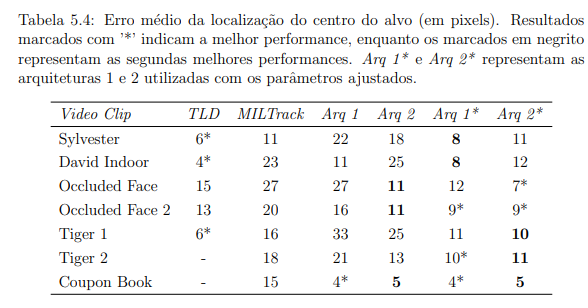